<a href="https://colab.research.google.com/github/Anurag-hue1/PRODIGY_ML_04/blob/main/task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install & Import
!pip install kagglehub -q
import kagglehub
import os

# 2. Download (Silent Mode)
print("Connecting to Kaggle and downloading LeapGestRecog (2.13 GB)...")
path = kagglehub.dataset_download("gti-upm/leapgestrecog")

# 3. Path Logic
DATASET_PATH = ""
for root, dirs, files in os.walk(path):
    if '00' in dirs:
        DATASET_PATH = root
        break

# 4. Final Output Verification
if DATASET_PATH:
    print("\n[SUCCESS] Dataset downloaded and verified.")
    print(f"Location: {DATASET_PATH}")
    print(f"Gestures found: {len(os.listdir(os.path.join(DATASET_PATH, '00')))} classes")
else:
    print("\n[ERROR] Dataset path not found.")

Connecting to Kaggle and downloading LeapGestRecog (2.13 GB)...
Using Colab cache for faster access to the 'leapgestrecog' dataset.

[SUCCESS] Dataset downloaded and verified.
Location: /kaggle/input/leapgestrecog/leapGestRecog
Gestures found: 10 classes


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

# 1. Identify Gestures (using subject '00' as a template)
sample_subject_path = os.path.join(DATASET_PATH, '00')
gesture_names = sorted([d for d in os.listdir(sample_subject_path) if os.path.isdir(os.path.join(sample_subject_path, d))])

lookup = {name: i for i, name in enumerate(gesture_names)}

def load_data():
    X = []
    y = []

    # We load subjects 00 through 04 (5 subjects) to keep training fast in Colab
    subjects = sorted([d for d in os.listdir(DATASET_PATH) if d.isdigit()])[0:5]

    print(f"Processing images for subjects: {subjects}...")
    for sub in subjects:
        sub_dir = os.path.join(DATASET_PATH, sub)
        for gesture in gesture_names:
            label = lookup[gesture]
            img_folder = os.path.join(sub_dir, gesture)

            for img_name in os.listdir(img_folder):
                if img_name.endswith(('.png', '.jpg', '.jpeg')):
                    try:
                        img_path = os.path.join(img_folder, img_name)
                        # LeapGestRecog images are infrared/grayscale
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        img = cv2.resize(img, (64, 64))
                        X.append(img)
                        y.append(label)
                    except Exception:
                        continue

    return np.array(X), np.array(y)

X, y = load_data()

# Reshape for CNN: (Samples, Height, Width, Channels)
X = X.reshape(-1, 64, 64, 1) / 255.0
y = to_categorical(y)

print(f"\nSuccessfully loaded {len(X)} images.")
print(f"Gesture Classes: {gesture_names}")

Processing images for subjects: ['00', '01', '02', '03', '04']...

Successfully loaded 10000 images.
Gesture Classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flattening and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Prevents overfitting
    Dense(len(gesture_names), activation='softmax') # Output layer for 10 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,866 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Starting training...")
history = model.fit(X_train, y_train,
                    epochs=7,
                    batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluate final accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")

Starting training...
Epoch 1/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.8170 - loss: 0.5562 - val_accuracy: 0.9975 - val_loss: 0.0142
Epoch 2/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.9821 - loss: 0.0649 - val_accuracy: 0.9995 - val_loss: 0.0036
Epoch 3/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - accuracy: 0.9846 - loss: 0.0459 - val_accuracy: 0.9995 - val_loss: 0.0018
Epoch 4/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 153ms/step - accuracy: 0.9901 - loss: 0.0300 - val_accuracy: 1.0000 - val_loss: 1.1138e-04
Epoch 5/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 150ms/step - accuracy: 0.9921 - loss: 0.0249 - val_accuracy: 1.0000 - val_loss: 6.3046e-04
Epoch 6/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 153ms/step - accuracy: 0.9927 - loss: 0.0220 - val_accuracy: 1.0000 - val_loss: 3.1104e-04
Epoch 7/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.9959 - loss: 0.0152 - val_accuracy: 0.9995 - val_loss: 6.7084e-04

Final Test Accuracy: 99.95%


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


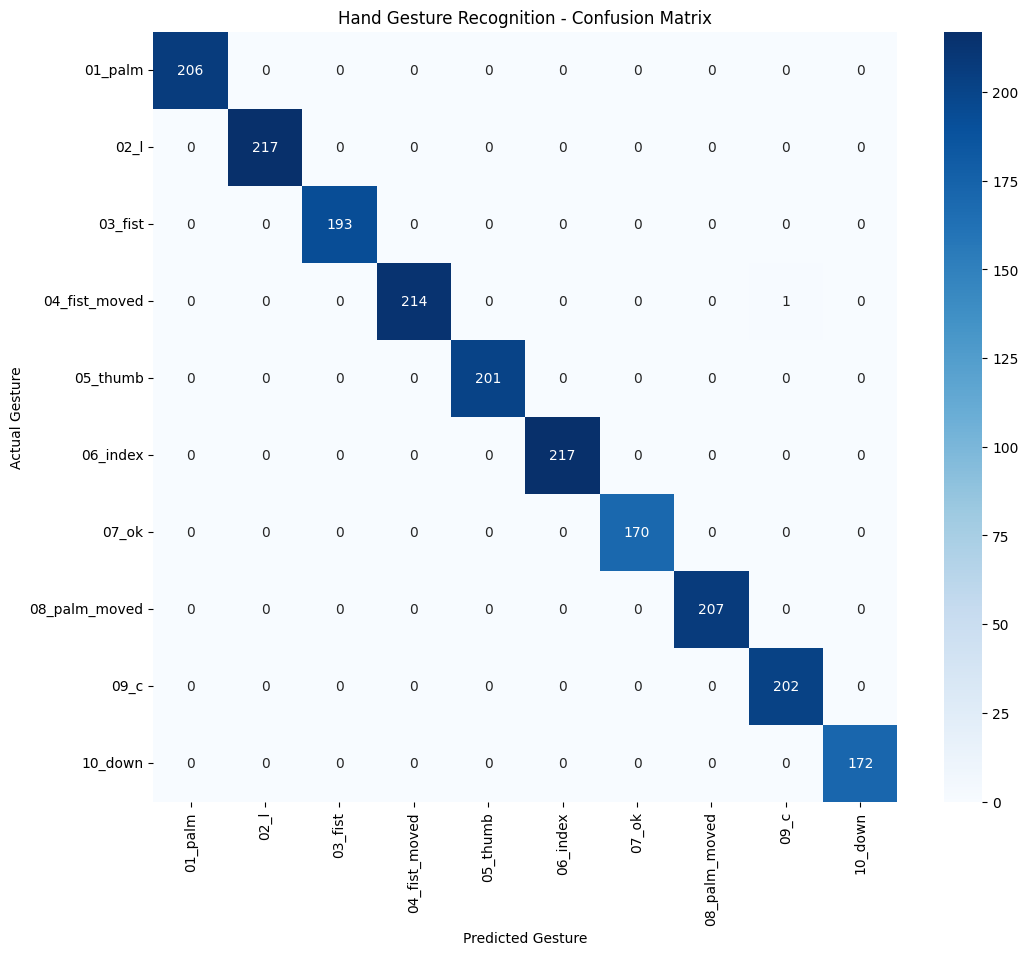

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_names,
            yticklabels=gesture_names)

plt.title('Hand Gesture Recognition - Confusion Matrix')
plt.xlabel('Predicted Gesture')
plt.ylabel('Actual Gesture')
plt.show()